## Fraud Detection System using Unsupervised ML and GenAI


### Project Overview
In modern digital banking ecosystems, rules-based fraud detection systems quickly fall short because financial cybercriminals continuously evolve their tactics. This project shifts away from rigid rulesets toward an anomaly-detection framework driven by unsupervised machine learning. By profiling normal transactional behavior based on data density and spatial proximity, the system isolates high-risk deviations in real-time.

### Steps Implemented
- Engineered an advanced feature pipeline from raw transactional datasets, extracting high-variance statistical and behavioral metrics to optimize anomaly detection capabilities.

- Implemented a multi-model unsupervised learning framework utilizing Isolation Forest and Local Outlier Factor (LOF) to isolate anomalous transaction patterns and flag high-risk fraudulent activity.

- Implemented a GenAI integrated dashboard that provides reasoning for considering a transaction as fraudulant


### Importing modules used and the dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('transaction_data.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


### Step 1: Data Cleaning
- checking for null values and mismatched datatypes

In [3]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y %H:%M')
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'], format='%d-%m-%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [4]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

There are no null values.

### Step2. Feature Engineering

Since there are two types of transactions: credit and debit, we need to create a signed amount indicating the flow of money.

In [5]:
df['DirectionalMultiplier'] = np.where(df['TransactionType'] == 'Credit', 1, -1)
df['SignedAmount'] = df['TransactionAmount'] * df['DirectionalMultiplier']

In [6]:
# 1. Sort the data chronologically (CRITICAL)
# If we skip this, our timeline is broken and our math is garbage.
df = df.sort_values(by=['AccountID', 'TransactionDate'])

# 2. Calculate the historical average transaction amount per account
# We use expanding().mean().shift(1) so the average ONLY looks at PAST transactions.
df['HistoricalAvgAmount'] = df.groupby('AccountID')['TransactionAmount'].transform(
    lambda x: x.expanding().mean().shift(1)
)
# If it is their very first transaction, there is no history. Fill NaN with their current amount.
df['HistoricalAvgAmount'] = df['HistoricalAvgAmount'].fillna(df['TransactionAmount'])

# 3. Create the Behavioral Ratio: How much bigger is this than their usual spend?
# A value of 1.0 means normal. A value of 50.0 means they just spent 50x their usual amount.
df['AmountVSHistoryRatio'] = df['TransactionAmount']/(df['HistoricalAvgAmount'] + 1)

# 4. Calculate Time Since Last Transaction (Velocity tracking)
# Hackers make back-to-back transactions rapidly. Normal users wait days.
df['DaysSinceLastTransaction'] = df.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds()/(24*3600)

# Fill the very first transaction for each user with a massive baseline (e.g., 999 days) 
# so the model knows it's a completely cold start
df['DaysSinceLastTransaction'] = df['DaysSinceLastTransaction'].fillna(999)

# 5.Track escalating failure counts
# A cumulative sum of login attempts leading up to this transaction
df['CumulativeLoginFails'] = df.groupby('AccountID')['LoginAttempts'].transform(
    lambda x:x.expanding().sum().shift(1)
).fillna(0)

# 6. Transaction amount by Account Balance
# A transaction bigger than the balance amount is obvious to raise some red flags
df['SignedBalanceRatio'] = df['SignedAmount']/df['AccountBalance']

### Step 3. EDA
Checking for skewness for potential features of our dataset

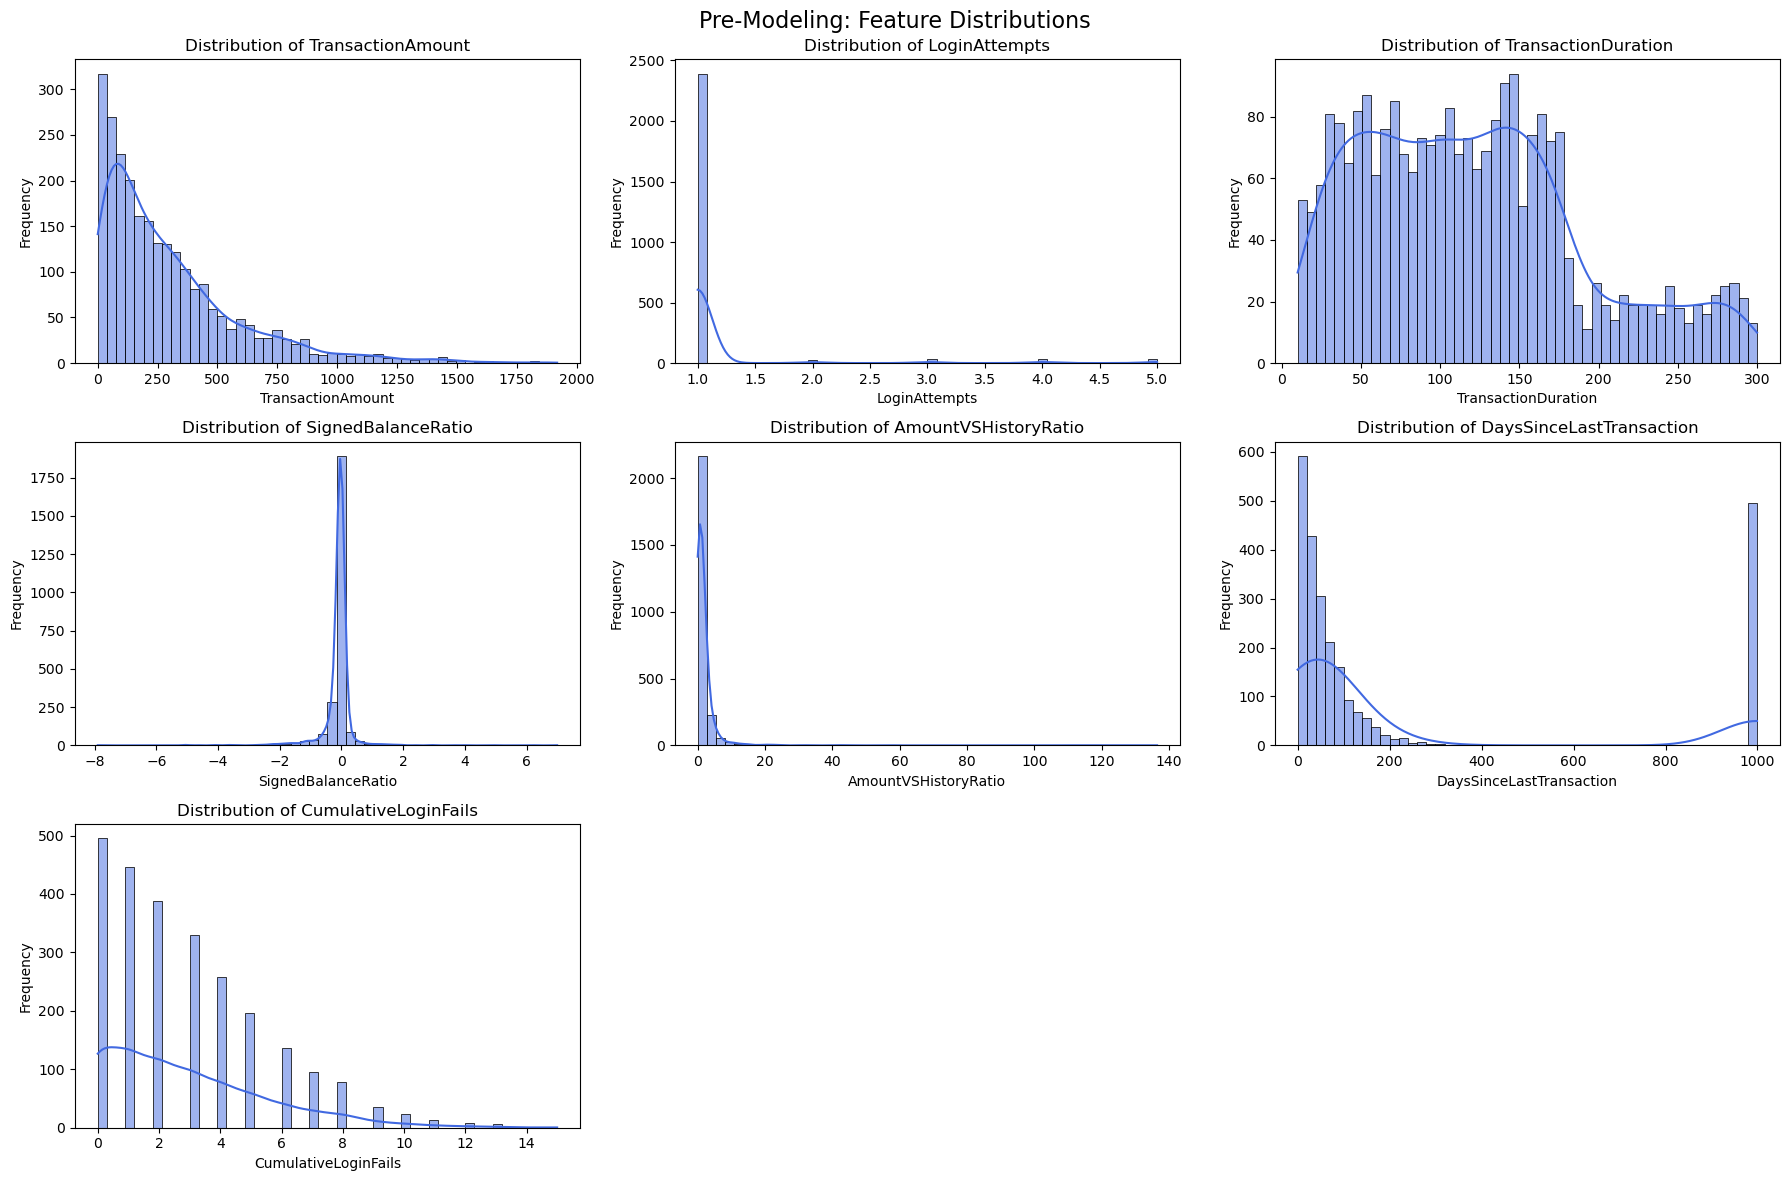

In [7]:
features = ['TransactionAmount', 'LoginAttempts', 'TransactionDuration', 
    'SignedBalanceRatio', 'AmountVSHistoryRatio', 
    'DaysSinceLastTransaction', 'CumulativeLoginFails']

fig, axes = plt.subplots(3, 3, figsize=(18,12))
fig.suptitle('Pre-Modeling: Feature Distributions', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

As we can see, that the `TransactionAmount`, `AmountVSHistoryRatio` and `DaysSinceLastTransaction` are extremely right skewed, so we transform them using log transformation. 

The IF model doesnt care for skewness, but the LOF model does, therefore the need for transformation

#### Creating the Feature Table

In [8]:
X = pd.DataFrame()
X['LoginAttempts'] = df['LoginAttempts']
X['TransactionDuration'] = df['TransactionDuration']
X['BalanceRatio'] = df['SignedBalanceRatio']
X['CumulativeLoginFails'] = df['CumulativeLoginFails'] 
X['TransactionAmount'] = np.log1p(df['TransactionAmount'])
X['DaysSinceLastTransaction'] = np.log1p(df['DaysSinceLastTransaction'])
X['AmountVSHistoryRatio'] = np.log1p(df['AmountVSHistoryRatio'])
X.head()

,LoginAttempts,TransactionDuration,BalanceRatio,CumulativeLoginFails,TransactionAmount,DaysSinceLastTransaction,AmountVSHistoryRatio
1312,1,37,-0.028965,0.0,3.887525,6.907755,0.682846
2016,1,178,-0.050945,1.0,5.365836,4.110828,1.679903
2120,1,187,-0.413164,0.0,6.169590,6.907755,0.692101
20,1,38,-0.010315,1.0,4.099664,3.912523,0.116985
1476,1,61,-0.001966,2.0,2.611539,4.204682,0.045821


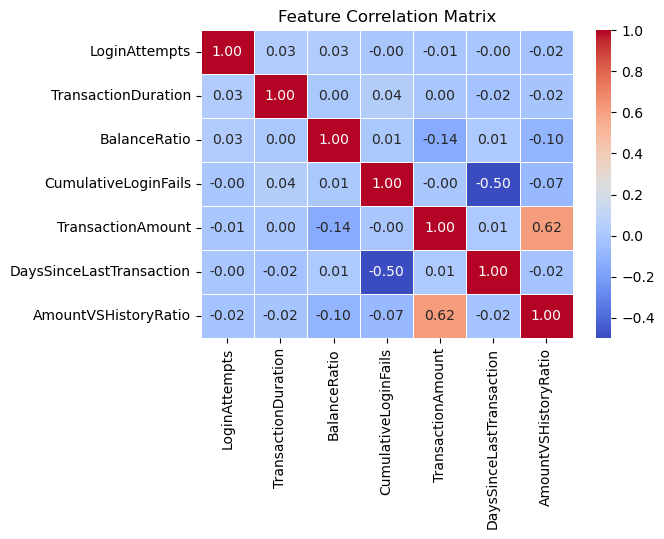

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

Since no feature correlates to the other that strongly(>0.9), we finalise this feature set


### Step4. Anomaly Detection
We use a combination of Local Outlier Factor and Isolation Forest, to finalize fraudulant transactions, with contamination set to 0.1, which for our dataset results in 26 anomalies flagged for each model. We then ensemble the transactions flagged by both the models, and present it to the user, so the final decision of whether a transaction is fraudulant or not lies with a human, rather than the model.

#### IsolationForest:
Isolation Forest isolates anomalies by randomly partitioning feature spaces. Because anomalies require fewer random splits to isolate than normal points packed tightly in a cluster, they surface at shallow tree depths.

#### LOF:
LOF ignores global limits entirely. It compares the local density of a point to the local densities of its $k$-nearest neighbors. If a point's local density is significantly lower than its neighbors, it is flagged as an outlier.

By using an union of both the flagged anomalies, we outline the complete risk perimeter, both the loud velocity spikes and the quiet takeovers.

In [10]:
## scaling the dataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
## Isolation Forest
model = IsolationForest(contamination=0.01, random_state=42)
df['AnomalyScore'] = model.fit_predict(X_scaled)

df['IFanomaly'] = df['AnomalyScore'].apply(lambda x: 1 if x==-1 else 0)
df['IFanomaly'].value_counts()

IFanomaly
0    2486
1      26
Name: count, dtype: int64

<Axes: xlabel='TransactionDuration', ylabel='TransactionAmount'>

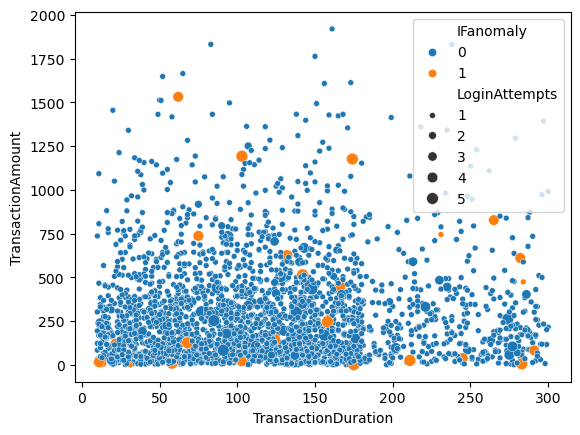

In [12]:
sns.scatterplot(data=df, x='TransactionDuration', y='TransactionAmount', hue='IFanomaly', size='LoginAttempts')

In [13]:
## LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)

df['lof_raw_score'] = lof.fit_predict(X_scaled)
df['LOFAnomaly'] = np.where(df['lof_raw_score']== -1, 1, 0)
df['LOFAnomaly'].value_counts()

LOFAnomaly
0    2486
1      26
Name: count, dtype: int64

<Axes: xlabel='TransactionDuration', ylabel='TransactionAmount'>

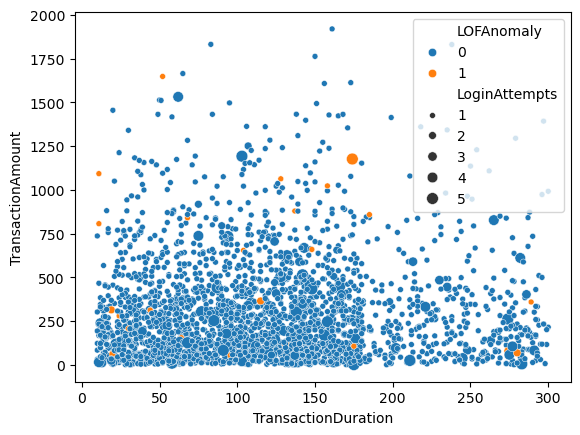

In [14]:
sns.scatterplot(data=df, x='TransactionDuration', y='TransactionAmount', hue='LOFAnomaly', size='LoginAttempts')

#### Combining the flags of both models

In [15]:
df['ensemble_flag'] = np.where(
    (df['IFanomaly']==1) | (df['LOFAnomaly']==1),
    1,
    0
)

In [16]:
df[df['ensemble_flag']==1].shape

(51, 28)

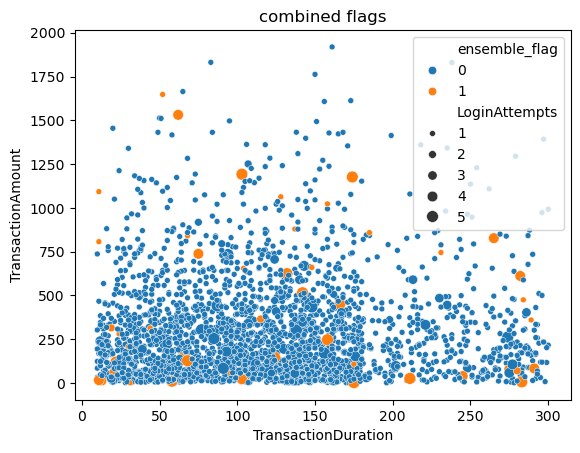

In [17]:
sns.scatterplot(data=df, x='TransactionDuration', y='TransactionAmount', hue='ensemble_flag', size='LoginAttempts')
plt.title('combined flags')
plt.show()

### Step5. GenAI Dashboard

In [18]:
import google.generativeai as genai
import os
from dotenv import load_dotenv

load_dotenv()

system_key = os.environ.get('GEMINI_API_KEY')
if not system_key:
    print("You still messed it up. The key is missing.")
else:
    genai.configure(api_key=system_key)
    print("API Key loaded successfully.")

API Key loaded successfully.


In [19]:
## Core logic of the llm model
def explain_anomaly_with_llm(row):

    prompt = f"""
    You are a Senior Risk Analyst at PwC evaluating an automated anomaly alert. 
    Your directive is to provide a balanced, nuanced risk assessment. Do NOT declare this as definite fraud. 
    Instead, analyze the tension between the demographic context and the financial behavior.

    System Classification Tier: {row['ensemble_flag']}
        
    Contextual Parameters:
    - Demographic: {row['CustomerAge']} year old {row['CustomerOccupation']}
    - Channel Used: {row['Channel']}
        
    Behavioral Metrics:
    - Transaction Amount: ${row['TransactionAmount']}
    - Balance Drain Ratio: {row['SignedBalanceRatio']:.2f}
    - Authentication Friction: {row['LoginAttempts']} failed login attempts prior to execution
        
    Chronological Account History:
    - Spend Deviation: {row['AmountVSHistoryRatio']:.2f}x their historical average
    - Account Velocity: {row['DaysSinceLastTransaction']:.1f} days since last transaction
    - Cumulative Friction: {row['CumulativeLoginFails']} total historical login failures
        
    Output a concise, professional assessment strictly using the following 4 sections:
    - 📊 **Trigger Metrics:** (Explicitly list the exact Transaction Amount, Balance Drain Ratio, and Login Attempts provided above).
    - 🔴 **Threat Hypothesis:** (1 sentence explaining exactly how these specific metrics align with malicious behavior, such as account takeover or credential stuffing).
    - 🟢 **Benign Scenario:** (1 sentence explaining a realistic, legitimate reason for this exact behavior based specifically on their age, occupation, or channel).
    - ⚖️ **Recommended Action:** (1 short sentence advising the human fraud team on what specific secondary data point they should check next to confirm or deny the threat).
        """ 
    try:
        ai_model = genai.GenerativeModel('gemini-3.1-flash-lite')
        response = ai_model.generate_content(prompt)
        return response.text
    except Exception as e:
        print(f"API Configuration Error: {e}")
        return e

#### Creating the Dashboard

In [20]:
import gradio as gr

anomalies_df = df[df['ensemble_flag'] == 1].copy()

def get_transaction_details(tx_id):
    if not tx_id:
        return "N/A", 'NO'

    # fetch the specific row
    row = anomalies_df[anomalies_df['TransactionID'] == tx_id].iloc[0]

    details = f"""
    ### Transaction Metadata
    * **Account ID:** `{row['AccountID']}`
    * **Device ID:** `{row['DeviceID']}`
    * **Transaction Amount:** `{row['TransactionAmount']}`
    * **Customer Occupation:** `{row['CustomerOccupation']}`
    * **Location:** `{row['Location']}`
    * **IP Address:** `{row['IP Address']}`
    * **Customer Age:** {row['CustomerAge']}
    * **Login Attempts:** {row['LoginAttempts']}
    * **Account Balance:** {row['AccountBalance']}
    * **Channel:** {row['Channel']}
    """ 

    explanation = explain_anomaly_with_llm(row)

    return details, explanation

# Build the UI Layout
with gr.Blocks(theme=gr.themes.Soft()) as dashboard:
    gr.Markdown('# GenAI Reasoning Dashboard')
    gr.Markdown("Select a flagged transaction to view its metadata and the LLM's justification for the anomaly")

    first_tx = anomalies_df['TransactionID'].iloc[0] if not anomalies_df.empty else None

    with gr.Row():
        # left sidebar for selection and quick stats
        with gr.Column(scale=1):
            tx_dropdown = gr.Dropdown(
                choices=anomalies_df['TransactionID'].tolist(),
                value=first_tx,
                label='Select Flagged Transaction ID'
            )

            gr.Markdown("---")
            tx_details = gr.Markdown(value='Select a transaction to view details...')

        #Right main area for the deep dive
        with gr.Column(scale=2):
            ai_explanation = gr.Textbox(
                label='GenAI Contextual Analysis',
                lines=6,
                interactive=False,
                placeholder='The LLMs reasoning will appear here...'
            )
    # map the inputs to the outputs when the dropdown changes
    tx_dropdown.change(
        fn=get_transaction_details,
        inputs=[tx_dropdown],
        outputs=[tx_details, ai_explanation]
    )
    dashboard.load(
        fn=get_transaction_details,
        inputs=[tx_dropdown],
        outputs=[tx_details, ai_explanation]
    )

dashboard.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## What's Next:

- Better fine-tune the models used, by implementing better scaling and transforming techniques.